### Implementing Bagging techniques

In [5]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd


In [6]:
df = pd.read_csv(r"E:\sculptsoft\25 June\heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
encoding_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df_encoded = pd.get_dummies(df, columns=encoding_cols, drop_first=True, dtype = int)
print(df_encoded.columns)

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [8]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1


In [9]:
df_encoded["HeartDisease"].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

In [10]:
X = df_encoded.drop(labels="HeartDisease", axis=1)
y = df_encoded.HeartDisease

In [11]:
X.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,1,0,1,0,1,0,0,0,1


In [12]:
y

0      0
1      1
2      0
3      1
4      0
      ..
913    1
914    1
915    1
916    1
917    0
Name: HeartDisease, Length: 918, dtype: int64

In [13]:
# accuracy score befor bagging

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
base_classifier = DecisionTreeClassifier()
tree_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
predictions = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
accuracy


0.8532608695652174

In [14]:
# accuracy after bagging

from sklearn.metrics import accuracy_score
bagging_classifier = BaggingClassifier()
bagging_classifier = BaggingClassifier(base_classifier, n_estimators=100, random_state=42)
bagging_classifier.fit(X_train, y_train)
y_pred = bagging_classifier.predict(X_test)
accuracy2 = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy2)

Accuracy: 0.8804347826086957


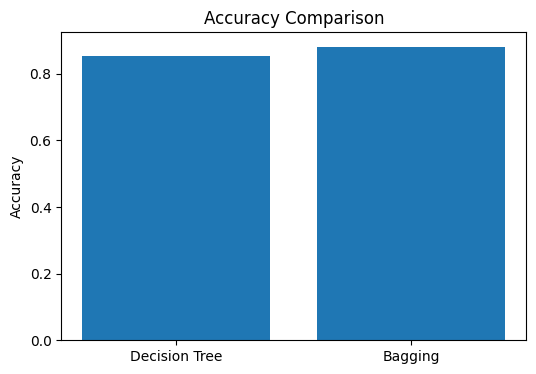

In [15]:
import matplotlib.pyplot as plt

accuracies = [accuracy, accuracy2]

plt.figure(figsize=(6,4))
plt.bar(
    ["Decision Tree", "Bagging"],
    accuracies
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.show()

In [16]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_classifier = AdaBoostClassifier(
    base_classifier, n_estimators=10, learning_rate=0.01, random_state=42
)
adaboost_classifier.fit(X_train, y_train)

y_pred = adaboost_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8532608695652174


In [17]:
from xgboost import XGBClassifier

In [18]:
from sklearn.metrics import classification_report

params = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10
}

model = XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.8641304347826086

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        77
           1       0.87      0.90      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184

